# 02 - ResNet-50 (ImageNet)

Trains **ResNet-50 (ImageNet)** on cached fundus crops with the frozen 5-fold splits; reports per-bigclass one-vs-rest AUC (Fig 2a style), macro AUC and frequency-weighted F1. All logic lives in `fundus_lib`.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, glob
# auto-locate the folder that actually contains fundus_lib
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("PROJECT_DIR ->", PROJECT_DIR)

DATA_ROOT   = os.path.join(PROJECT_DIR, "1000images")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache_crops")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MANIFEST    = os.path.join(PROJECT_DIR, "manifest_cached.json")
SPLITS      = os.path.join(PROJECT_DIR, "splits.json")
os.makedirs(RESULTS_DIR, exist_ok=True)

%pip install -q timm transformers torchinfo grad-cam

sys.path.insert(0, PROJECT_DIR)
import fundus_lib as fl
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| imported fundus_lib OK")


Mounted at /content/drive
PROJECT_DIR -> /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 108.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda | imported fundus_lib OK


## Load frozen manifest + splits

In [2]:
import json, numpy as np
manifest = json.load(open(MANIFEST))
splits   = fl.data.load_splits(SPLITS)
folds    = np.array(splits["fold_of_index"])
MODEL_NAME = "resnet50"
EPOCHS = 100
BATCH = 16
c2i, i2c = fl.data.class_index_maps(range(10))
NUM_CLASSES = len(c2i)
train_tf, eval_tf = fl.models.get_transforms(MODEL_NAME)
print("model:", MODEL_NAME, "| classes:", NUM_CLASSES)

model: resnet50 | classes: 10


## 5-fold cross-validation

In [3]:
from torch.utils.data import DataLoader
fold_metrics, all_true, all_prob, histories = [], [], [], []
for test_fold in range(splits["n_splits"]):
    tr_idx, va_idx, te_idx = fl.data.fold_indices(folds, test_fold)
    ds_tr = fl.data.FundusDataset(manifest, tr_idx, train_tf, c2i)
    ds_va = fl.data.FundusDataset(manifest, va_idx, eval_tf, c2i)
    ds_te = fl.data.FundusDataset(manifest, te_idx, eval_tf, c2i)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True, num_workers=2)
    dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=2)
    dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
    tr_labels = [c2i[manifest[i]["bigclass"]] for i in tr_idx]
    cw = fl.engine.class_weights_from_labels(tr_labels, NUM_CLASSES, device)
    model = fl.models.build_model(MODEL_NAME, NUM_CLASSES)
    print(f"\n=== fold {test_fold} | train {len(tr_idx)} val {len(va_idx)} test {len(te_idx)} ===")
    model, hist = fl.engine.fit(model, dl_tr, dl_va, device, NUM_CLASSES,
                                epochs=EPOCHS, class_weights=cw, verbose=True)
    yt, yp = fl.engine.evaluate(model, dl_te, device)
    m = fl.metrics.compute_metrics(yt, yp, index_to_class=i2c)
    print("  fold %d: wF1=%.3f macroAUC=%.3f wAUC=%.3f" % (test_fold, m["weighted_f1"], m["macro_auc"], m["weighted_auc"]))
    fold_metrics.append(m); all_true.append(yt); all_prob.append(yp); histories.append(hist)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]



=== fold 0 | train 330 val 110 test 111 ===


/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.0992 val_loss 1.4159 | train_acc 0.339 val_acc 0.664 | val_wF1 0.6379
  epoch  1 | train_loss 1.1624 val_loss 0.7633 | train_acc 0.736 val_acc 0.773 | val_wF1 0.7797
  epoch  2 | train_loss 0.5524 val_loss 0.5123 | train_acc 0.864 val_acc 0.855 | val_wF1 0.8393
  epoch  3 | train_loss 0.3077 val_loss 0.7080 | train_acc 0.909 val_acc 0.818 | val_wF1 0.8155
  epoch  4 | train_loss 0.3286 val_loss 0.5743 | train_acc 0.897 val_acc 0.818 | val_wF1 0.8145
  epoch  5 | train_loss 0.2379 val_loss 0.3882 | train_acc 0.933 val_acc 0.873 | val_wF1 0.8771
  epoch  6 | train_loss 0.2078 val_loss 0.2992 | train_acc 0.942 val_acc 0.918 | val_wF1 0.9168
  epoch  7 | train_loss 0.1356 val_loss 0.4151 | train_acc 0.967 val_acc 0.927 | val_wF1 0.9290
  epoch  8 | train_loss 0.1000 val_loss 0.2355 | train_acc 0.973 val_acc 0.964 | val_wF1 0.9642
  epoch  9 | train_loss 0.1491 val_loss 0.3037 | train_acc 0.970 val_acc 0.909 | val_wF1 0.9058
  epoch 10 | train_loss 0.0863 val_loss 

...

  epoch  0 | train_loss 2.0814 val_loss 1.6118 | train_acc 0.372 val_acc 0.645 | val_wF1 0.6194
  epoch  1 | train_loss 1.1062 val_loss 0.6281 | train_acc 0.810 val_acc 0.818 | val_wF1 0.8125
  epoch  2 | train_loss 0.4622 val_loss 0.6223 | train_acc 0.873 val_acc 0.855 | val_wF1 0.8611
  epoch  3 | train_loss 0.4088 val_loss 0.5644 | train_acc 0.870 val_acc 0.836 | val_wF1 0.8338
  epoch  4 | train_loss 0.2653 val_loss 0.9324 | train_acc 0.915 val_acc 0.809 | val_wF1 0.8128
  epoch  5 | train_loss 0.2434 val_loss 0.4990 | train_acc 0.946 val_acc 0.855 | val_wF1 0.8546
  epoch  6 | train_loss 0.2043 val_loss 0.3336 | train_acc 0.949 val_acc 0.873 | val_wF1 0.8699
  epoch  7 | train_loss 0.2639 val_loss 0.4094 | train_acc 0.958 val_acc 0.891 | val_wF1 0.8882
  epoch  8 | train_loss 0.1413 val_loss 0.3975 | train_acc 0.949 val_acc 0.900 | val_wF1 0.9039
  epoch  9 | train_loss 0.1475 val_loss 0.3471 | train_acc 0.955 val_acc 0.927 | val_wF1 0.9252
  epoch 10 | train_loss 0.1255 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.0942 val_loss 1.4810 | train_acc 0.332 val_acc 0.691 | val_wF1 0.6754
  epoch  1 | train_loss 1.0621 val_loss 0.5923 | train_acc 0.740 val_acc 0.818 | val_wF1 0.8234
  epoch  2 | train_loss 0.5315 val_loss 0.4926 | train_acc 0.819 val_acc 0.845 | val_wF1 0.8488
  epoch  3 | train_loss 0.3011 val_loss 0.5377 | train_acc 0.894 val_acc 0.855 | val_wF1 0.8637
  epoch  4 | train_loss 0.2125 val_loss 0.5215 | train_acc 0.906 val_acc 0.855 | val_wF1 0.8584
  epoch  5 | train_loss 0.1782 val_loss 0.1558 | train_acc 0.943 val_acc 0.955 | val_wF1 0.9537
  epoch  6 | train_loss 0.1357 val_loss 0.2531 | train_acc 0.967 val_acc 0.909 | val_wF1 0.9161
  epoch  7 | train_loss 0.2382 val_loss 0.1976 | train_acc 0.927 val_acc 0.945 | val_wF1 0.9445
  epoch  8 | train_loss 0.1657 val_loss 0.8682 | train_acc 0.943 val_acc 0.882 | val_wF1 0.8820
  epoch  9 | train_loss 0.1468 val_loss 0.8347 | train_acc 0.979 val_acc 0.882 | val_wF1 0.8848
  epoch 10 | train_loss 0.1645 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.0845 val_loss 1.4100 | train_acc 0.324 val_acc 0.622 | val_wF1 0.5828
  epoch  1 | train_loss 1.0203 val_loss 0.6706 | train_acc 0.736 val_acc 0.775 | val_wF1 0.7996
  epoch  2 | train_loss 0.6144 val_loss 0.9173 | train_acc 0.830 val_acc 0.793 | val_wF1 0.7983
  epoch  3 | train_loss 0.3391 val_loss 0.4676 | train_acc 0.918 val_acc 0.874 | val_wF1 0.8744
  epoch  4 | train_loss 0.1943 val_loss 0.3778 | train_acc 0.930 val_acc 0.901 | val_wF1 0.8999
  epoch  5 | train_loss 0.1582 val_loss 0.2705 | train_acc 0.967 val_acc 0.928 | val_wF1 0.9263
  epoch  6 | train_loss 0.1576 val_loss 0.6778 | train_acc 0.948 val_acc 0.874 | val_wF1 0.8745
  epoch  7 | train_loss 0.1920 val_loss 0.4225 | train_acc 0.952 val_acc 0.910 | val_wF1 0.9107
  epoch  8 | train_loss 0.1858 val_loss 0.5858 | train_acc 0.942 val_acc 0.856 | val_wF1 0.8584
  epoch  9 | train_loss 0.0664 val_loss 0.3351 | train_acc 0.976 val_acc 0.883 | val_wF1 0.8847
  epoch 10 | train_loss 0.1026 val_loss 

## Aggregate + save

In [4]:
import numpy as np, json, torch
summary = fl.metrics.aggregate_folds(fold_metrics)
print("=== %s : 5-fold summary ===" % MODEL_NAME)
for k in ["weighted_auc","macro_auc","weighted_f1","macro_f1","balanced_accuracy","accuracy"]:
    print("  %-20s %.3f +/- %.3f" % (k, summary[k+"_mean"], summary[k+"_std"]))
pooled = fl.metrics.compute_metrics(np.concatenate(all_true), np.concatenate(all_prob), i2c)
out = {"model": MODEL_NAME, "summary": summary,
       "per_fold": [{k:v for k,v in m.items() if not isinstance(v,dict)} for m in fold_metrics],
       "per_class_auc_pooled": pooled["per_class_auc"]}
json.dump(out, open(os.path.join(RESULTS_DIR, "metrics_%s.json" % MODEL_NAME), "w"), indent=2)
np.savez(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME),
         y_true=np.concatenate(all_true), y_prob=np.concatenate(all_prob))
json.dump(histories, open(os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME), "w"), indent=2)
# also save last fold weights so the grad-cam cells can reload after restart
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME))
print("saved metrics_%s.json, preds_%s.npz, history_%s.json, weights_%s_last_fold.pth"
      % (MODEL_NAME, MODEL_NAME, MODEL_NAME, MODEL_NAME))


=== resnet50 : 5-fold summary ===
  weighted_auc         0.997 +/- 0.002
  macro_auc            0.997 +/- 0.002
  weighted_f1          0.936 +/- 0.032
  macro_f1             0.922 +/- 0.035
  balanced_accuracy    0.931 +/- 0.029
  accuracy             0.935 +/- 0.033
saved metrics_resnet50.json, preds_resnet50.npz, history_resnet50.json, weights_resnet50_last_fold.pth


## Visualize: training curves + per-disease ROC (Fig 2a-style)

Loss/accuracy curves from `history_resnet50.json`; ROC curves from pooled `preds_resnet50.npz`.


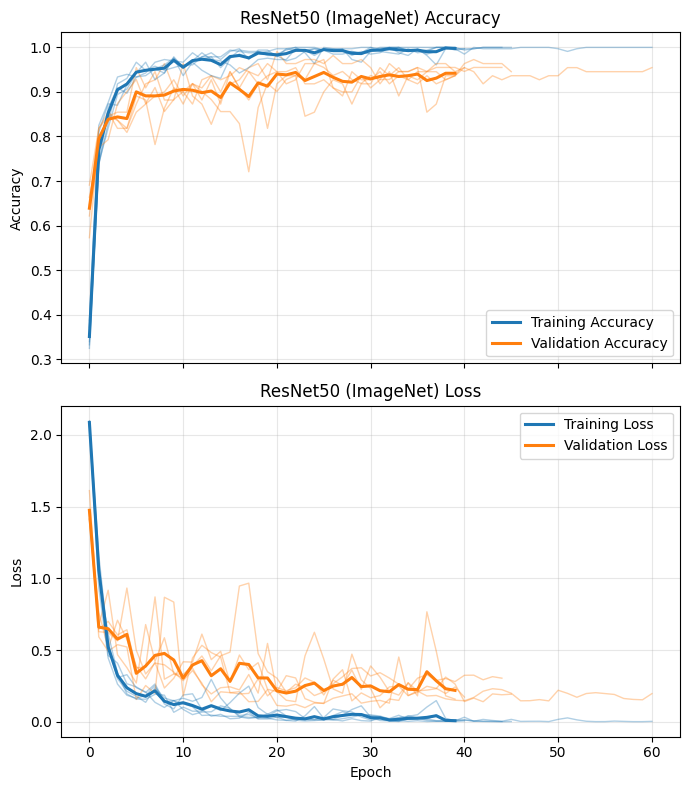

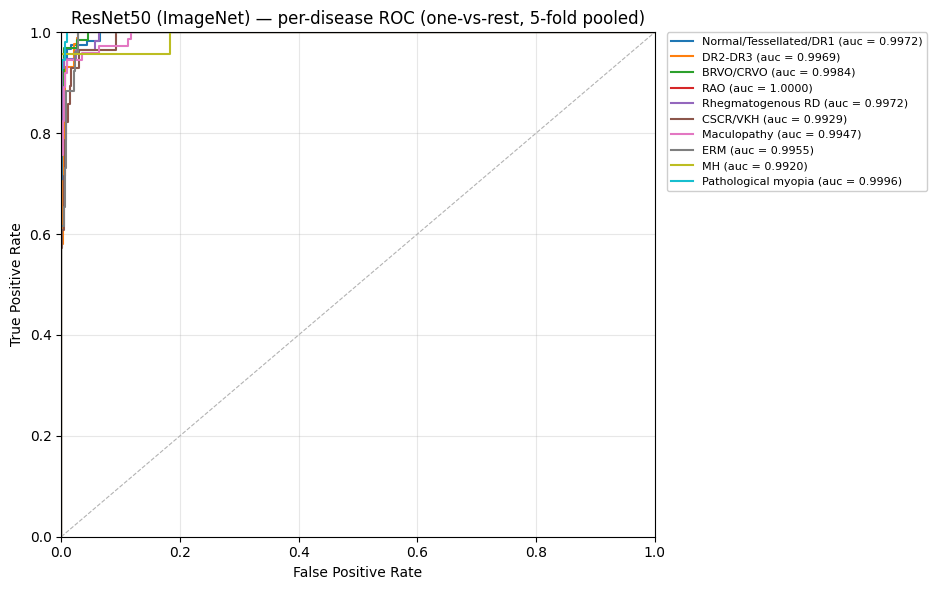


per-class AUC (one-vs-rest, pooled across folds):
  RAO                            1.0000
  Pathological myopia            0.9996
  BRVO/CRVO                      0.9984
  Normal/Tessellated/DR1         0.9972
  Rhegmatogenous RD              0.9972
  DR2-DR3                        0.9969
  ERM                            0.9955
  Maculopathy                    0.9947
  CSCR/VKH                       0.9929
  MH                             0.9920


In [5]:
import os, sys, glob, json, numpy as np, matplotlib.pyplot as plt

# auto-locate fundus_lib + force-reload so newest helpers are picked up
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
for mod in [m for m in list(sys.modules) if m == "fundus_lib" or m.startswith("fundus_lib.")]:
    del sys.modules[mod]
import fundus_lib as fl
import fundus_lib.metrics  # noqa

hist_path = os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME)
if os.path.exists(hist_path):
    histories = json.load(open(hist_path))
    fl.metrics.plot_history(histories, model_name="ResNet50 (ImageNet)",
        save_path=os.path.join(RESULTS_DIR, "history_%s.png" % MODEL_NAME))
    plt.show()
else:
    print("no saved history — re-run the 5-fold cell so train/val loss + accuracy are recorded")

preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = {k: fl.metrics.bigclass_short[k] for k in range(NUM_CLASSES)}
fl.metrics.plot_roc_per_class(
    y_true_all, y_prob_all, index_to_class=short,
    title="ResNet50 (ImageNet) — per-disease ROC (one-vs-rest, 5-fold pooled)",
    save_path=os.path.join(RESULTS_DIR, "roc_per_class_%s.png" % MODEL_NAME),
)
plt.show()

per_class = fl.metrics.compute_metrics(y_true_all, y_prob_all, index_to_class=short)["per_class_auc"]
print("\nper-class AUC (one-vs-rest, pooled across folds):")
for name, auc in sorted(per_class.items(), key=lambda kv: -kv[1] if not np.isnan(kv[1]) else 0):
    print(f"  {name:30s} {auc:.4f}")


## Grad-CAM: where is ResNet50 (ImageNet) looking?

Uses `fl.models.gradcam_setup(MODEL_NAME, model)` which returns the right target layer and reshape transform per architecture (last conv block for ResNet; last-block pre-attention LayerNorm + token→spatial reshape for ViT/DINOv2/RETFound).


In [6]:
import os, json, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
build_args = dict()
gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES, **build_args).to(device)
if "model" in globals() and isinstance(model, torch.nn.Module):
    gradcam_model.load_state_dict(model.state_dict())
    print("using in-memory last-fold model")
elif os.path.exists(ckpt_path):
    gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("loaded weights from", ckpt_path)
else:
    raise RuntimeError("no trained model available — re-run training first")
gradcam_model.eval()

target_layers, reshape = fl.models.gradcam_setup(MODEL_NAME, gradcam_model)

last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1); y_conf = yp.max(1)

short = fl.metrics.bigclass_short
selected = []
for k in range(NUM_CLASSES):
    mask = (yt == k) & (y_pred == k)
    if not mask.any(): continue
    cand = np.where(mask)[0]
    selected.append((int(cand[int(np.argmax(y_conf[cand]))]), int(k)))
print(f"showing {len(selected)} bigclasses (best correct per class, fold {last_test_fold})")

def _prepare(local_i):
    row = ds_te.rows[local_i]
    raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
    rgb = np.asarray(raw, dtype=np.float32) / 255.0
    input_tensor, _ = ds_te[local_i]
    return input_tensor, rgb

cam = GradCAM(model=gradcam_model, target_layers=target_layers, reshape_transform=reshape)

n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(11, 3.2 * n))
if n == 1: axes = axes.reshape(1, -1)
for r, (li, k) in enumerate(selected):
    input_tensor, rgb = _prepare(li)
    targets = [ClassifierOutputTarget(int(y_pred[li]))]
    heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
    overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)
    axes[r,0].imshow(rgb); axes[r,0].axis("off")
    axes[r,0].set_title(f"original — {short[k]}", fontsize=9, fontweight="bold")
    axes[r,1].imshow(heatmap, cmap="jet"); axes[r,1].axis("off")
    axes[r,1].set_title(f"Grad-CAM (pred={short[int(y_pred[li])]}, p={y_conf[li]:.2f})", fontsize=9)
    axes[r,2].imshow(overlay); axes[r,2].axis("off")
    axes[r,2].set_title("overlay", fontsize=9)
plt.suptitle(f"ResNet50 (ImageNet) — Grad-CAM on fold {last_test_fold} test set (best correct per bigclass)",
             fontsize=11, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "gradcam_%s.png" % MODEL_NAME), dpi=150, bbox_inches="tight")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## Class balance + per-fold counts

Context for the per-class AUC numbers — a class with 18 images can hit 0.69 AUC just from sampling noise.


In [7]:
import numpy as np
from collections import Counter

short = fl.metrics.bigclass_short
bc_of_idx = np.array([m["bigclass"] for m in manifest])
total = Counter(bc_of_idx.tolist())
per_fold = {f: Counter(bc_of_idx[folds == f].tolist()) for f in range(splits["n_splits"])}

hdr = f'{"bigclass":<26s}{"total":>7s}' + "".join(f'{"fold"+str(f):>7s}' for f in range(splits["n_splits"]))
print(hdr); print("-" * len(hdr))
for k in range(NUM_CLASSES):
    bc = i2c[k]
    row = f'{short[k]:<26s}{total.get(bc,0):>7d}'
    row += "".join(f'{per_fold[f].get(bc,0):>7d}' for f in range(splits["n_splits"]))
    print(row)
print("-" * len(hdr))
tot = f'{"TOTAL":<26s}{sum(total.values()):>7d}'
tot += "".join(f'{sum(per_fold[f].values()):>7d}' for f in range(splits["n_splits"]))
print(tot)


bigclass                    total  fold0  fold1  fold2  fold3  fold4
--------------------------------------------------------------------
Normal/Tessellated/DR1        119     24     24     24     24     23
DR2-DR3                        88     18     18     17     17     18
BRVO/CRVO                      66     13     13     14     13     13
RAO                            16      3      3      3      4      3
Rhegmatogenous RD              57     12     11     11     11     12
CSCR/VKH                       28      5      6      6      6      5
Maculopathy                    74     15     15     15     14     15
ERM                            26      5      5      5      6      5
MH                             23      5      5      4      4      5
Pathological myopia            54     11     10     11     11     11
--------------------------------------------------------------------
TOTAL                         551    111    110    110    110    110


## Confusion matrix (pooled OOF predictions)

Row-normalized (each row sums to 1 = sensitivity for that true class); raw counts in parentheses.


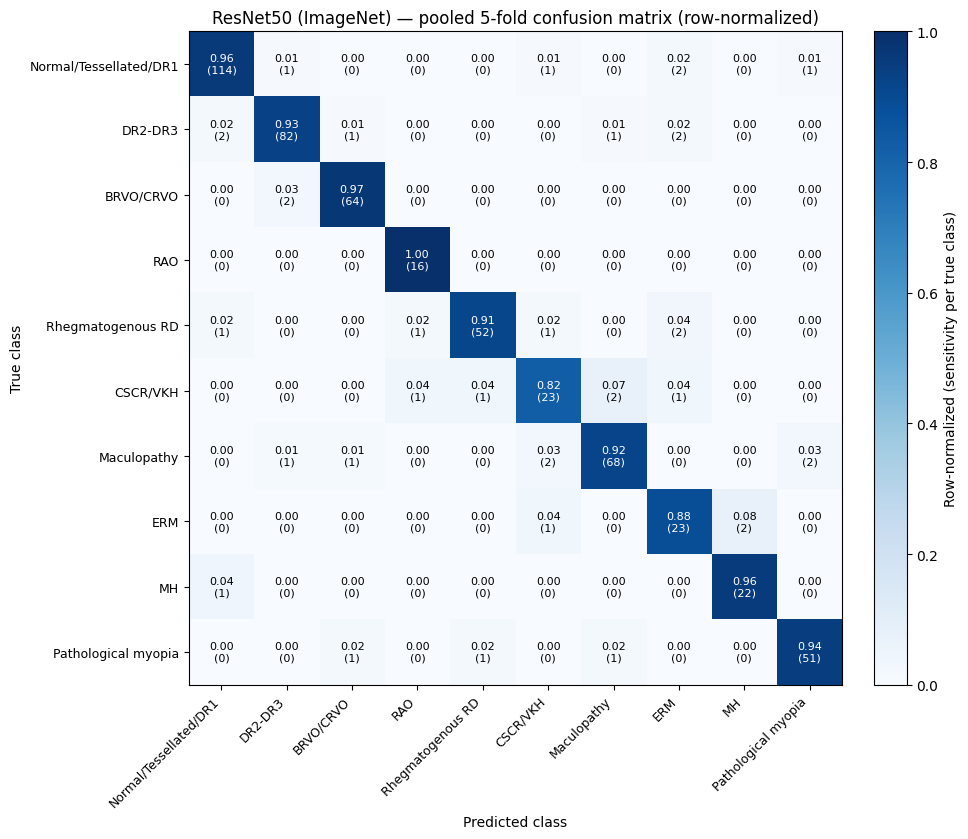

In [8]:
import os, numpy as np, matplotlib.pyplot as plt

preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = fl.metrics.bigclass_short

fl.metrics.plot_confusion_matrix(
    y_true_all, y_prob_all, index_to_class=short, normalize="true",
    title="ResNet50 (ImageNet) — pooled 5-fold confusion matrix (row-normalized)",
    save_path=os.path.join(RESULTS_DIR, "confusion_%s.png" % MODEL_NAME),
)
plt.show()


## Grad-CAM on failure cases

Highest-confidence wrong predictions in the last fold, target = predicted class (what convinced the model). DeGrave et al. (*Nat Mach Intell* 2021) caught most COVID X-ray classifiers as shortcut-learners this way.


showing top 6 highest-confidence wrong predictions (of 6 failures)


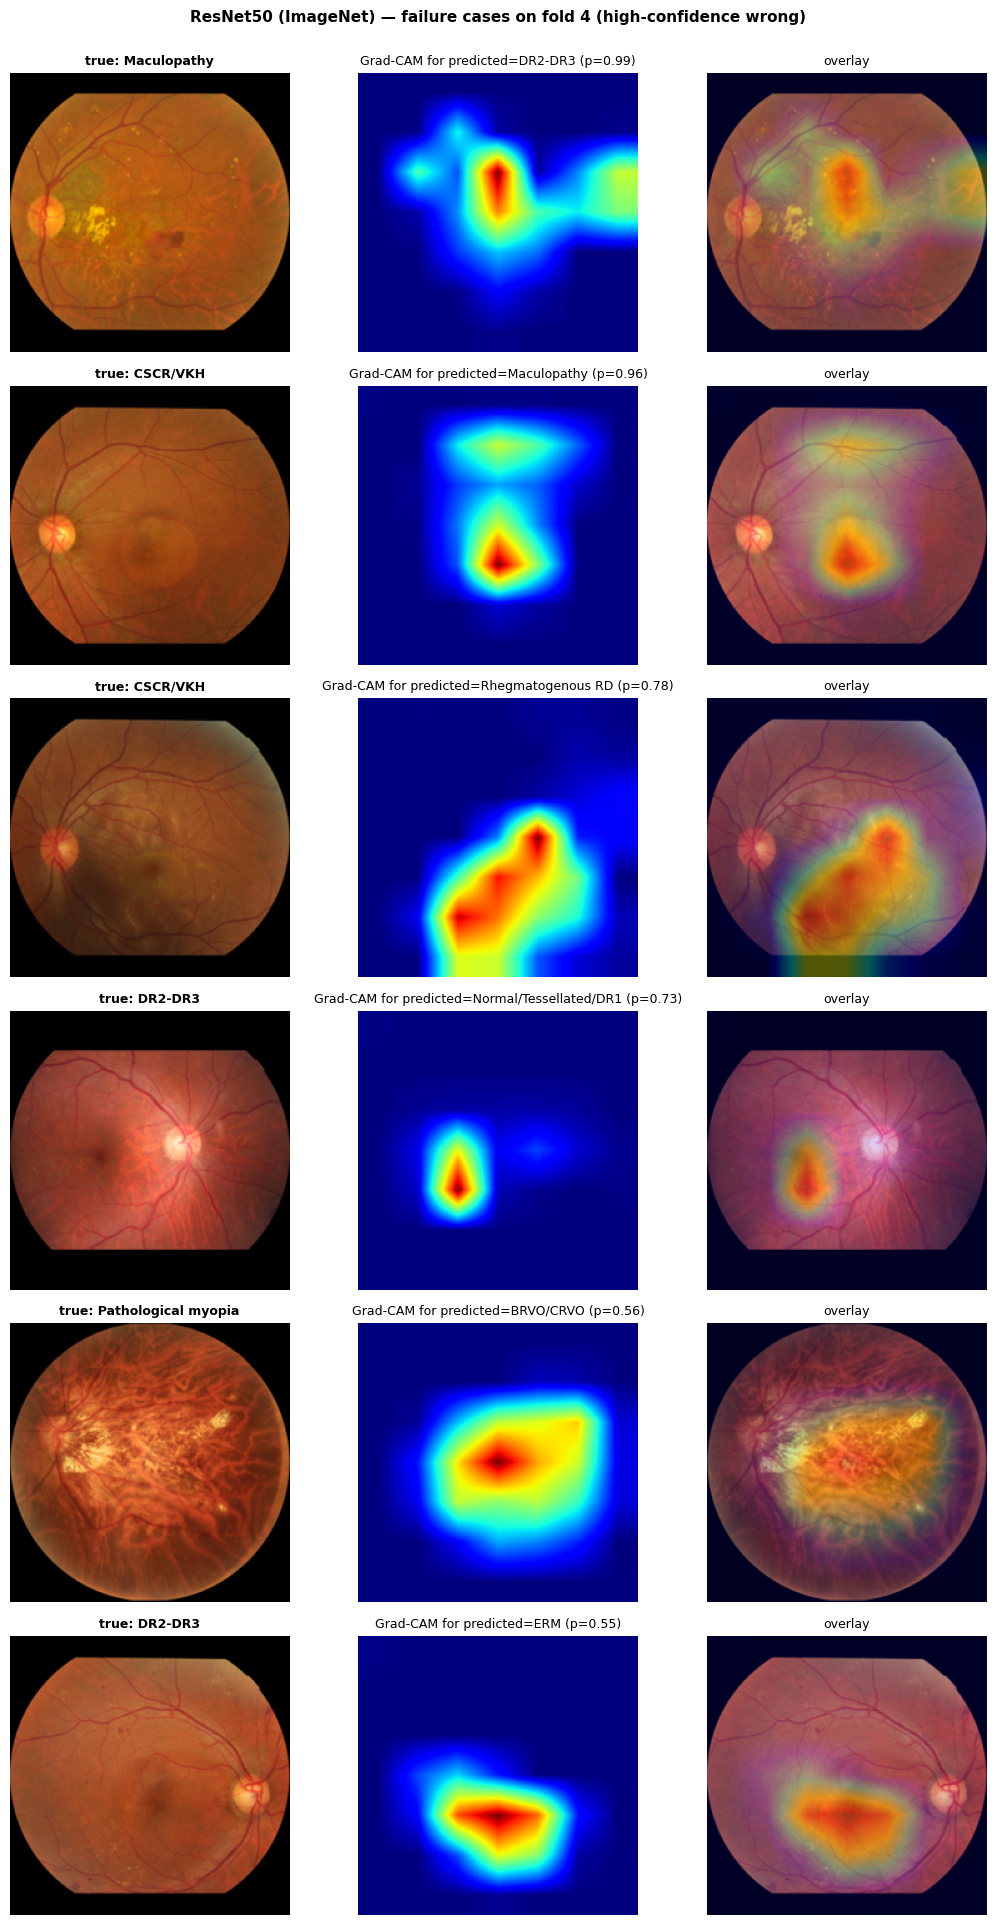

In [9]:
import os, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

if "gradcam_model" not in globals():
    ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
    build_args = dict()
    gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES, **build_args).to(device)
    if "model" in globals() and isinstance(model, torch.nn.Module):
        gradcam_model.load_state_dict(model.state_dict())
    elif os.path.exists(ckpt_path):
        gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    else:
        raise RuntimeError("no trained model available")
    gradcam_model.eval()

target_layers, reshape = fl.models.gradcam_setup(MODEL_NAME, gradcam_model)

last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1); y_conf = yp.max(1)
short = fl.metrics.bigclass_short

wrong = np.where(y_pred != yt)[0]
if len(wrong) == 0:
    print("no failures on the last fold")
else:
    order = wrong[np.argsort(-y_conf[wrong])]
    n_show = min(6, len(order))
    picks = order[:n_show]
    print(f"showing top {n_show} highest-confidence wrong predictions (of {len(wrong)} failures)")

    def _prepare(local_i):
        row = ds_te.rows[local_i]
        raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
        rgb = np.asarray(raw, dtype=np.float32) / 255.0
        input_tensor, _ = ds_te[local_i]
        return input_tensor, rgb

    cam = GradCAM(model=gradcam_model, target_layers=target_layers, reshape_transform=reshape)
    fig, axes = plt.subplots(n_show, 3, figsize=(11, 3.2 * n_show))
    if n_show == 1: axes = axes.reshape(1, -1)
    for r, li in enumerate(picks):
        input_tensor, rgb = _prepare(int(li))
        targets = [ClassifierOutputTarget(int(y_pred[li]))]
        heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
        overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)
        true_name = short[int(yt[li])]; pred_name = short[int(y_pred[li])]
        axes[r,0].imshow(rgb); axes[r,0].axis("off")
        axes[r,0].set_title(f"true: {true_name}", fontsize=9, fontweight="bold")
        axes[r,1].imshow(heatmap, cmap="jet"); axes[r,1].axis("off")
        axes[r,1].set_title(f"Grad-CAM for predicted={pred_name} (p={y_conf[li]:.2f})", fontsize=9)
        axes[r,2].imshow(overlay); axes[r,2].axis("off")
        axes[r,2].set_title("overlay", fontsize=9)
    plt.suptitle(f"ResNet50 (ImageNet) — failure cases on fold {last_test_fold} (high-confidence wrong)",
                 fontsize=11, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "gradcam_failures_%s.png" % MODEL_NAME), dpi=150, bbox_inches="tight")
    plt.show()
